In [597]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno


In [598]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [599]:
df_productivity = pd.read_csv(PATH)


In [600]:
print("Dataset shape:", df_productivity.shape)

print("\n--- INFO ---")
df_productivity.info()

print("\n--- DESCRIPTIVE STATISTICS  ---")
display(df_productivity.describe())

print("\n--- FIRST ROWS ---")
display(df_productivity.head())

print("\n--- COLUMNS ---")
print(df_productivity.columns.tolist())

Dataset shape: (3248, 34)

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324



--- FIRST ROWS ---


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,2025-11-28,review,finalized,JIRA-49014,true,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,2026-01-26,delivered,client_review,JIRA-84793,false,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,2025-09-17,in_progress,qa,JIRA-42485,true,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,2025-11-12,in_progress,briefing,JIRA-53111,false,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,2026-05-09,review,execution,JIRA-86006,true,v2



--- COLUMNS ---
['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'created_at', 'delivered_at', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


In [601]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Numerical columns: ['task_complexity_score', 'brief_quality_score', 'scope_change_flag', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'revenue', 'cost', 'profit']

Categorical columns: ['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'created_at', 'delivered_at', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version']


# Duplicates check

In [602]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [603]:
dup_count = df_productivity.duplicated(subset='task_id').sum()

print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [604]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)


In [605]:
dup_count = df_productivity.duplicated(subset='task_id').sum()

print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


# Team normalization

In [606]:
df_productivity['team'] = df_productivity['team'].str.strip()


print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))


df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)


print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))


print('\nDistribution:')
print(df_productivity['team'].value_counts(dropna=False))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']

Distribution:
team
Content    827
Media      805
Design     790
SEO        778
Name: count, dtype: int64


# Date Parsing

In [607]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} values NaT after the conversion")



df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days


mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")


if neg_count > 0:
    print(df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head())
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan


print("\nduration_days:")
print(df_productivity['duration_days'].describe().round(1))

created_at: 0 values NaT after the conversion
delivered_at: 38 values NaT after the conversion

Negative durations found: 14
     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0

duration_days:
count    3148.0
mean        4.5
std         1.8
min         0.0
25%         3.0
50%         5.0
75%         6.0
max        10.0
Name: duration_days, dtype: float64


## Legacy AI Flag Cleaning


In [608]:
print("Before cleaning:")
print(df_productivity['legacy_ai_flag'].value_counts(dropna=False))

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)


df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)


df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
print(df_productivity['legacy_ai_flag'].value_counts(dropna=False))


ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")

Before cleaning:
legacy_ai_flag
false      1436
true       1427
unknown     337
Name: count, dtype: int64

After cleaning:
legacy_ai_flag
0.0    1436
1.0    1427
NaN     337
Name: count, dtype: int64

Correlation with AI usage indicator: -0.014


## MISSING VALUES

In [609]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

legacy_ai_flag         337
jira_ticket            331
ai_usage_pct           143
outcome_score          132
billable_hours          81
rework_hours            72
brief_quality_score     68
duration_days           52
delivered_at            38
sla_days                34
dtype: int64

In [610]:
missing_pct = (df_productivity.isnull().sum() / len(df_productivity) * 100)
missing_pct.sort_values(ascending=False)

legacy_ai_flag           10.53125
jira_ticket              10.34375
ai_usage_pct              4.46875
outcome_score             4.12500
billable_hours            2.53125
rework_hours              2.25000
brief_quality_score       2.12500
duration_days             1.62500
delivered_at              1.18750
sla_days                  1.06250
task_complexity_score     0.00000
team                      0.00000
content_version           0.00000
project_id                0.00000
client_tier               0.00000
workflow_stage            0.00000
task_status               0.00000
updated_at                0.00000
created_by                0.00000
profit                    0.00000
cost                      0.00000
revenue                   0.00000
errors                    0.00000
task_type                 0.00000
deadline_pressure         0.00000
revisions                 0.00000
ai_assisted               0.00000
seniority                 0.00000
client                    0.00000
hours_spent   

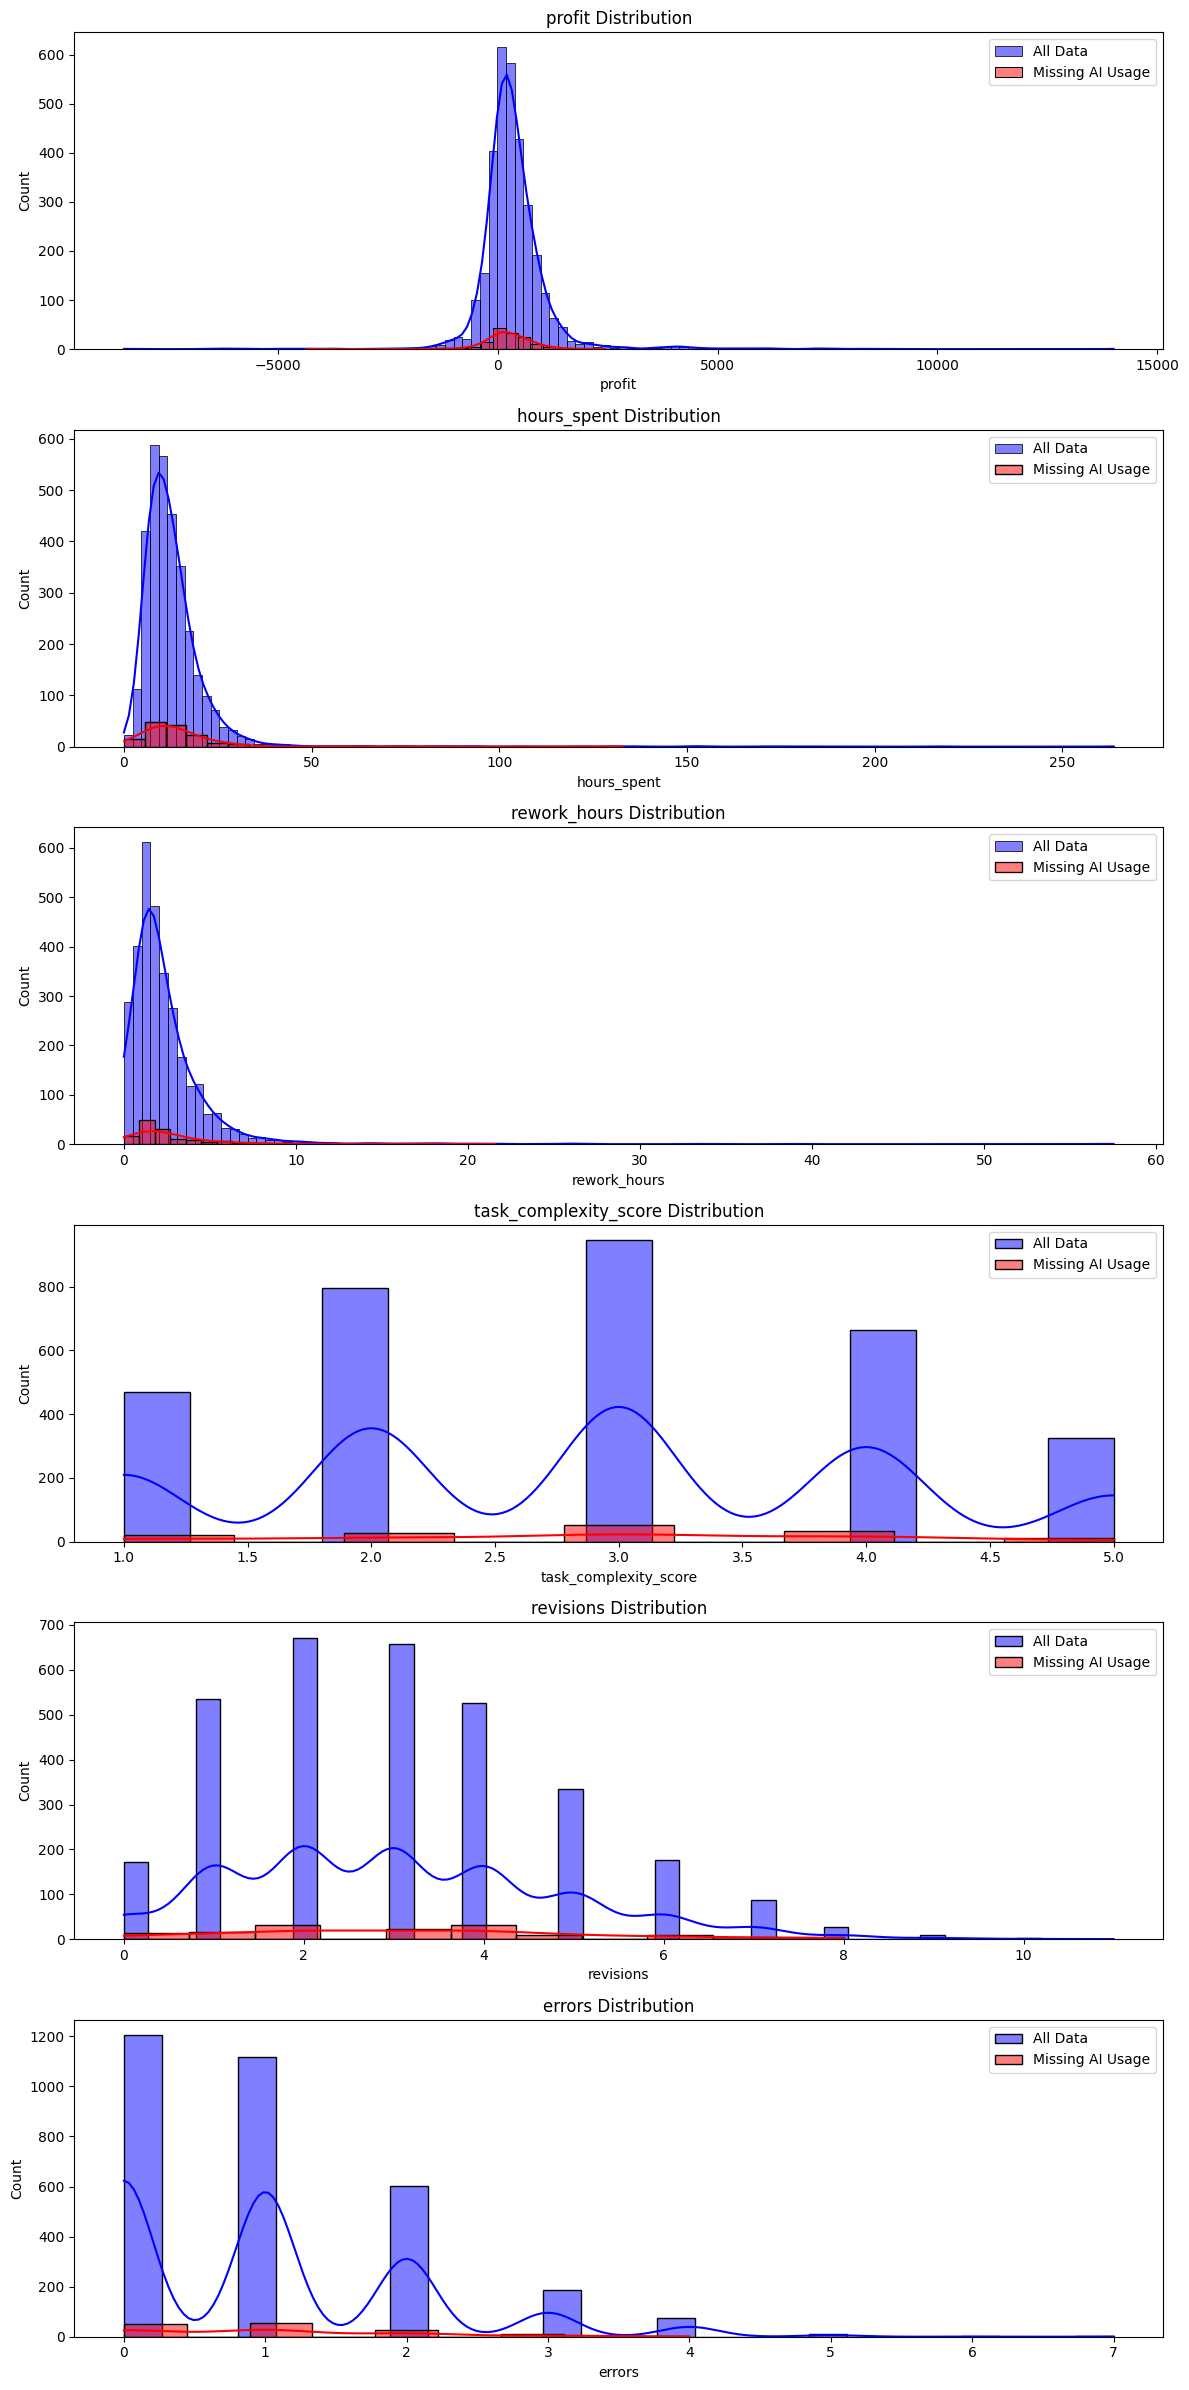

In [611]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]


columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors'
]


fig, axes = plt.subplots(len(columns), 1, figsize=(12, 4 * len(columns)))


for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, x=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, x=column, ax=axes[i], color='red', label='Missing AI Usage')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()


plt.tight_layout()
plt.show()

<Axes: >

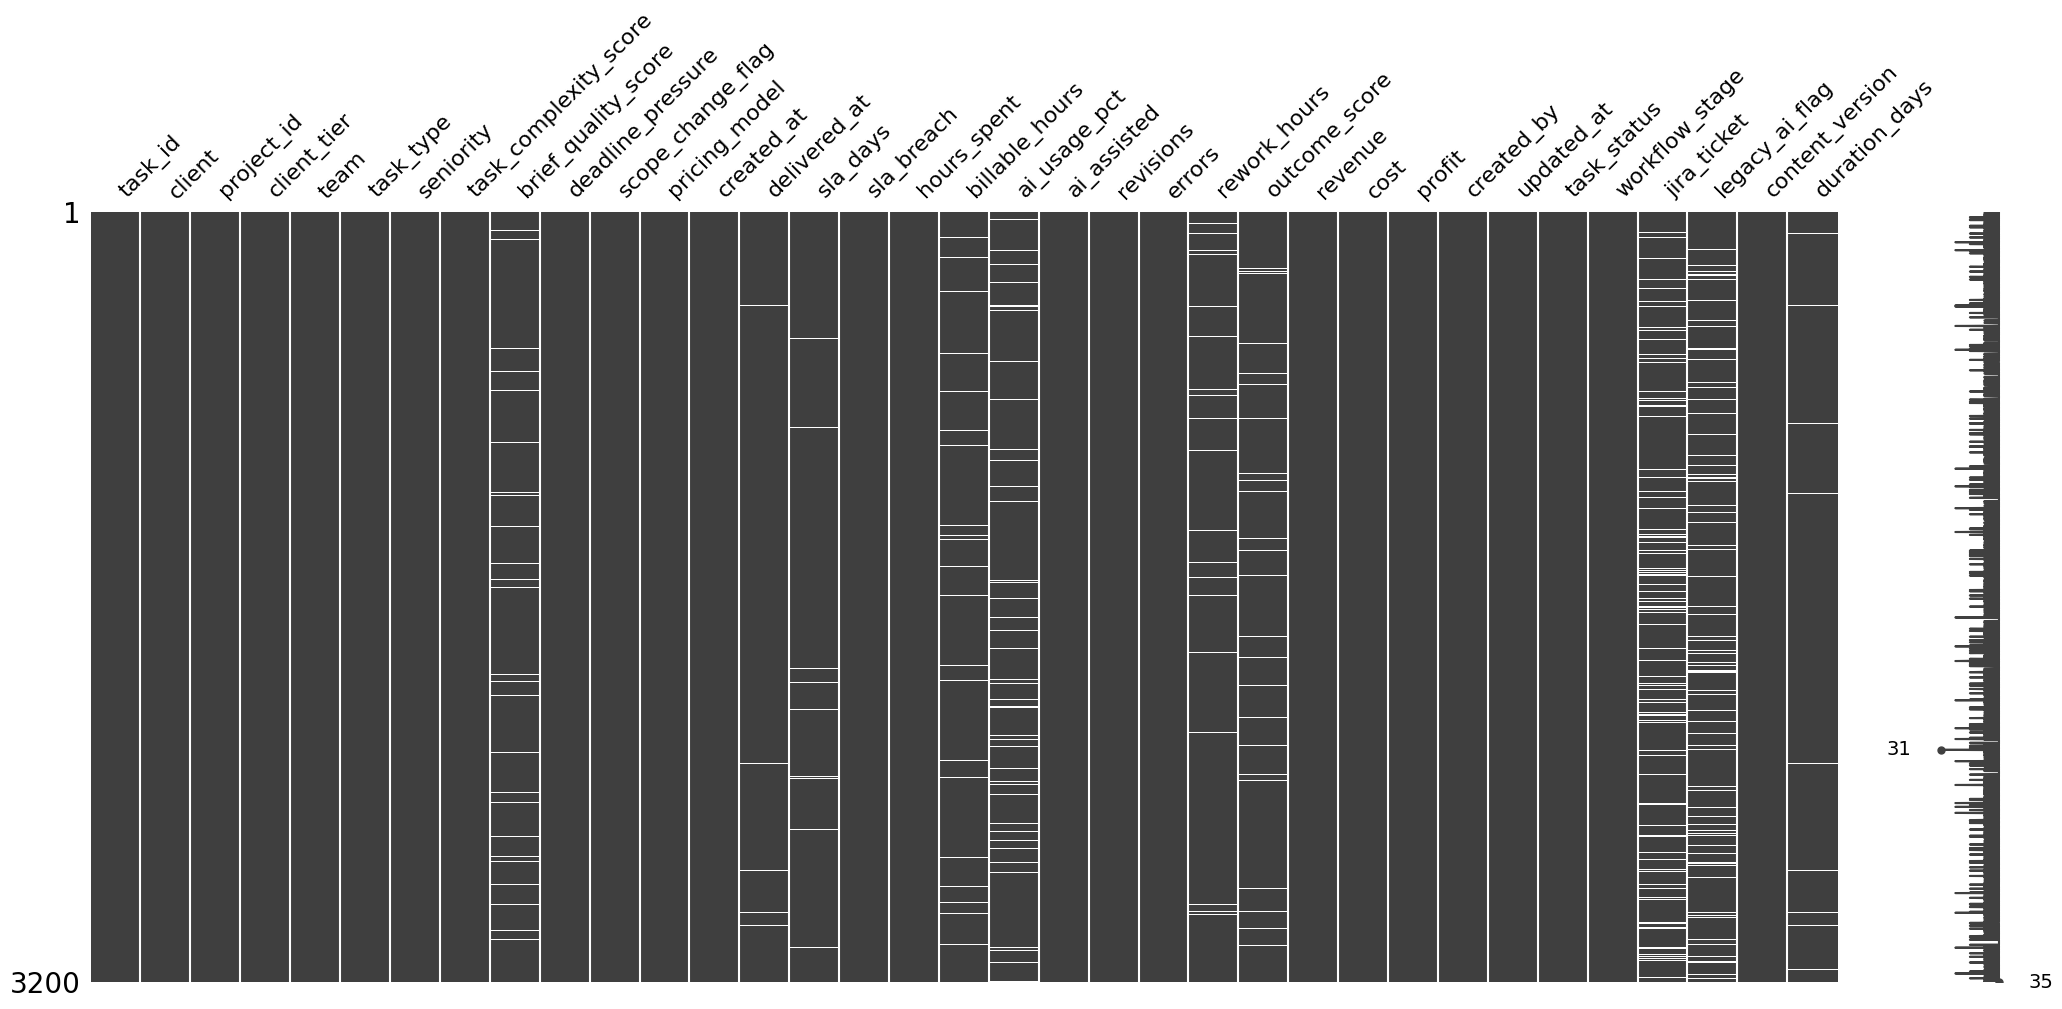

In [612]:
msno.matrix(df_productivity)

**taking care of nans**

In [613]:
df_productivity = df_productivity.drop(columns=['jira_ticket'], errors='ignore')



df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(
    df_productivity['ai_usage_pct'].median()
)

df_productivity['outcome_score'] = df_productivity['outcome_score'].fillna(
    df_productivity['outcome_score'].median()
)

df_productivity['brief_quality_score'] = df_productivity['brief_quality_score'].fillna(
    df_productivity['brief_quality_score'].median()
)

df_productivity['sla_days'] = df_productivity['sla_days'].fillna(
    df_productivity['sla_days'].median()
)



mask = df_productivity['billable_hours'].isna()

df_productivity.loc[mask, 'billable_hours'] = (
    df_productivity.loc[mask, 'hours_spent'] * 0.85
)



df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(
    df_productivity['rework_hours'].median()
)


remaining = df_productivity.isnull().sum()
remaining = remaining[remaining > 0]

print("\nRemaining missing values:")
print(remaining)


Remaining missing values:
delivered_at       38
legacy_ai_flag    337
duration_days      52
dtype: int64


# Outlier check


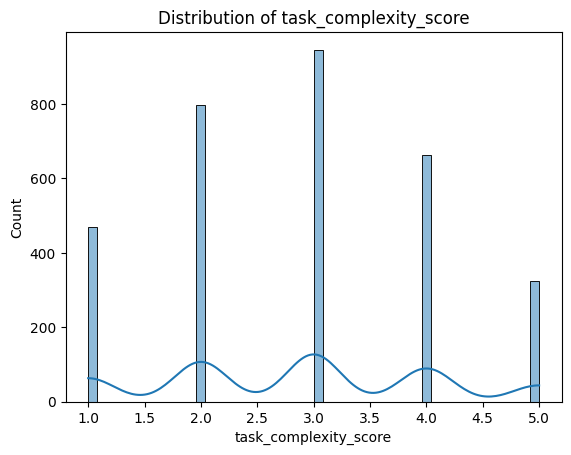

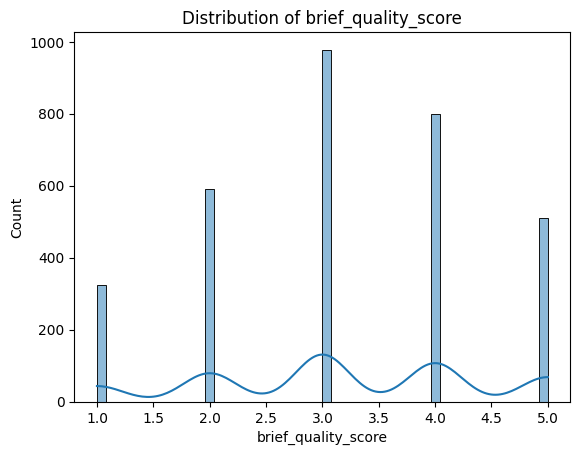

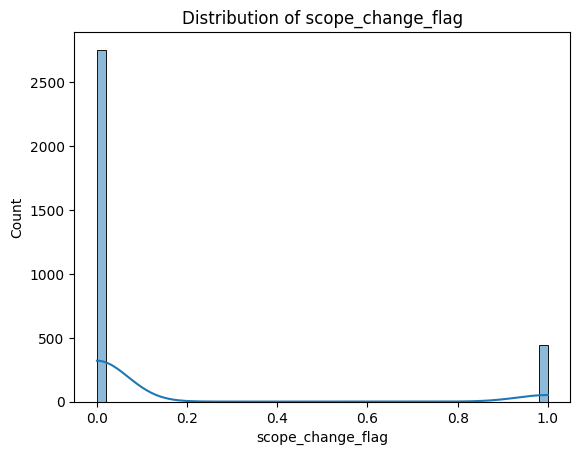

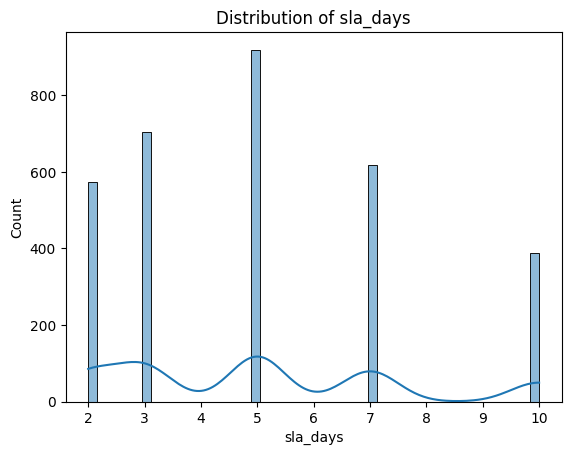

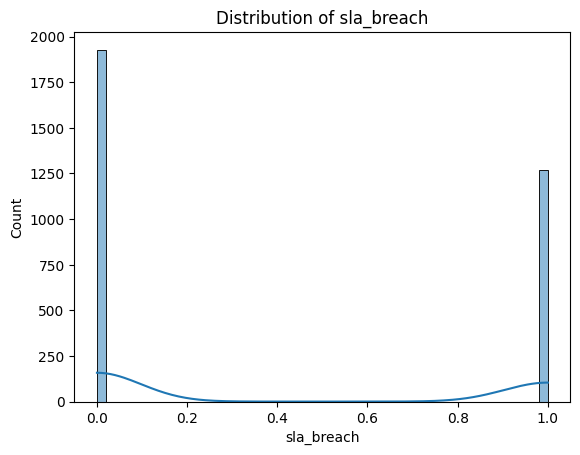

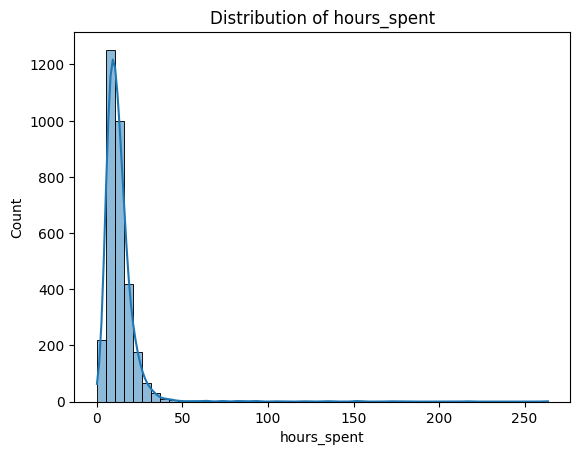

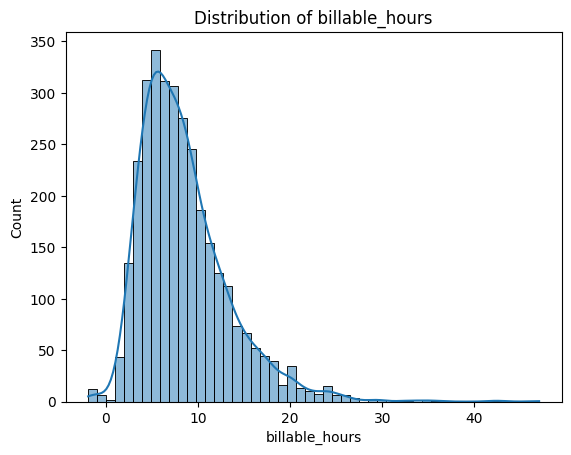

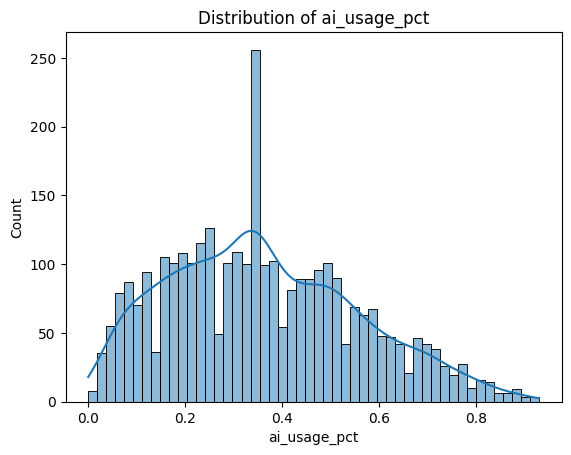

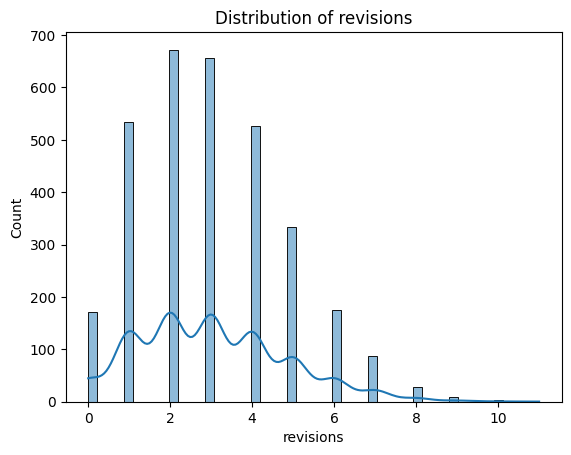

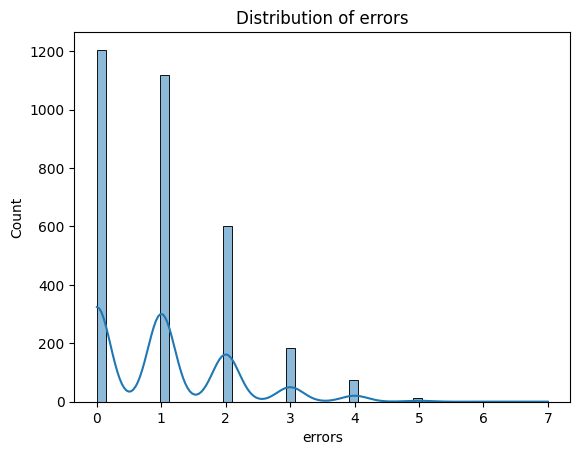

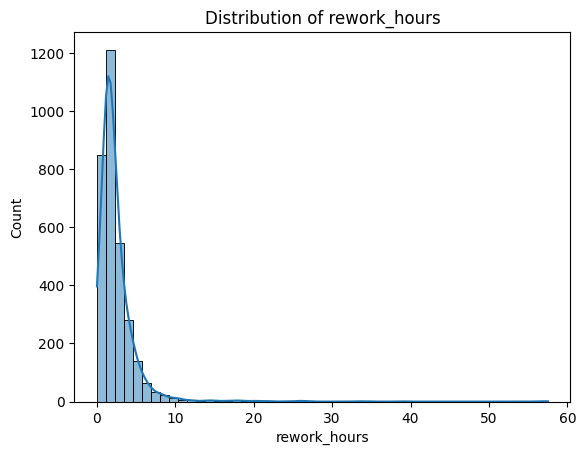

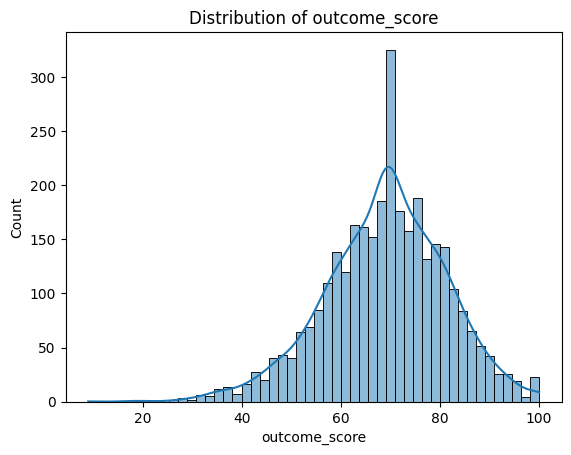

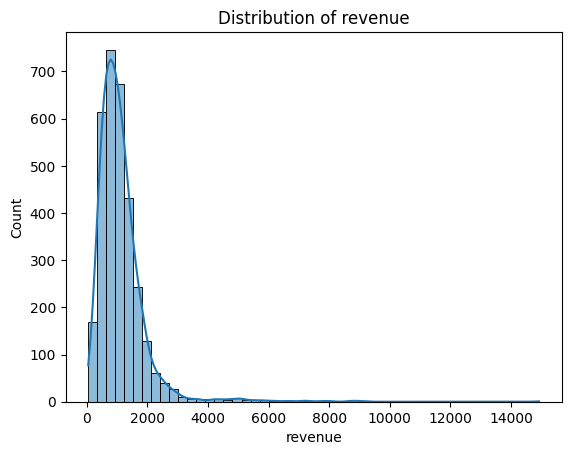

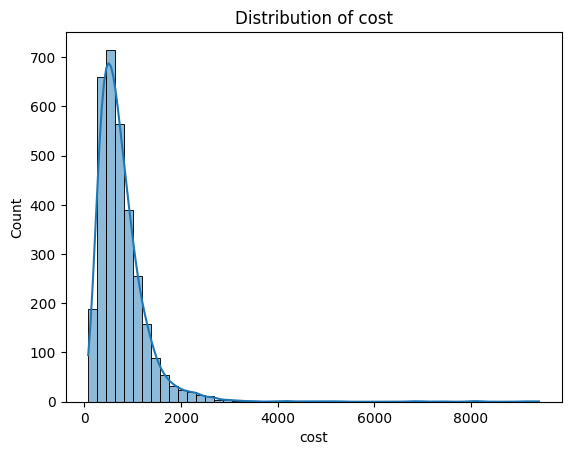

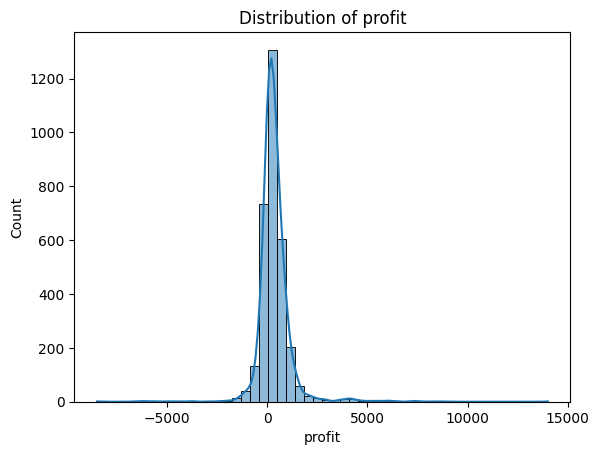

In [614]:
for col in num_cols:
    plt.figure()
    sns.histplot(df_productivity[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')


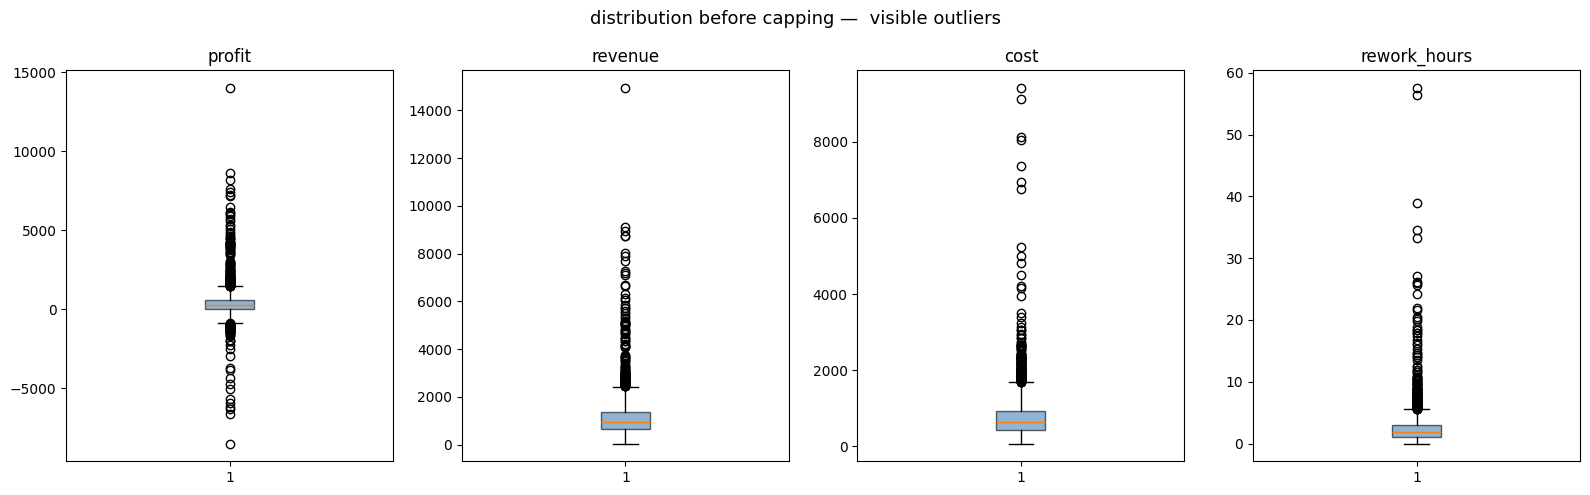

estreme outlier (IQR × 3):



In [615]:
cap_cols = ['profit', 'revenue', 'cost', 'rework_hours']

fig, axes = plt.subplots(1, len(cap_cols), figsize=(16, 5))
for i, col in enumerate(cap_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('distribution before capping —  visible outliers', fontsize=13)
plt.tight_layout()
plt.show()

print("estreme outlier (IQR × 3):\n")

In [616]:
for col in cap_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    n_out = ((df_productivity[col] < lower) | 
             (df_productivity[col] > upper)).sum()
    pct = n_out / len(df_productivity) * 100
    print(f"  {col:<15} lower={lower:>8.2f}  upper={upper:>8.2f}  "
          f"outliers={n_out} ({pct:.1f}%)")



  profit          lower=-1777.78  upper= 2365.62  outliers=79 (2.5%)
  revenue         lower=-1510.15  upper= 3521.39  outliers=54 (1.7%)
  cost            lower=-1067.79  upper= 2447.60  outliers=38 (1.2%)
  rework_hours    lower=   -4.28  upper=    8.32  outliers=71 (2.2%)


In [617]:
def cap_iqr(series, k=3):
    q1    = series.quantile(0.25)
    q3    = series.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n_capped = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n_capped

print("\nCapping applicato:\n")
for col in cap_cols:
    if col in df_productivity.columns:
        df_productivity[col], n = cap_iqr(df_productivity[col])
        print(f"  {col:<15} {n} capped values")


Capping applicato:

  profit          79 capped values
  revenue         54 capped values
  cost            38 capped values
  rework_hours    71 capped values



 Final shape: (3200, 34)


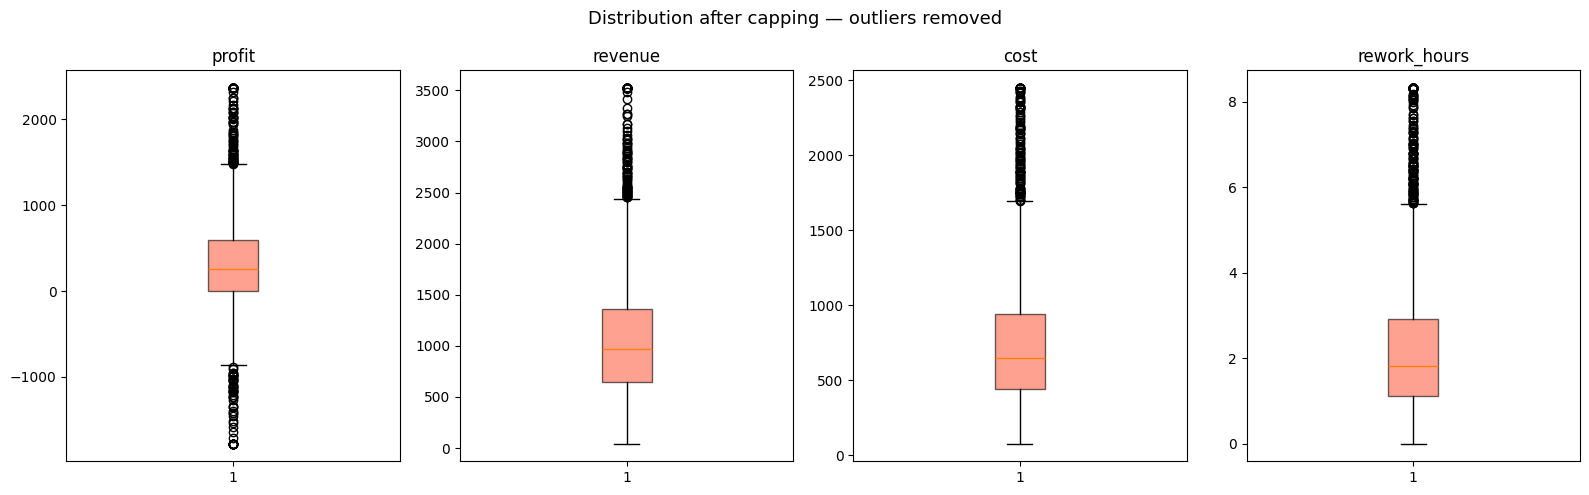

In [618]:
fig, axes = plt.subplots(1, len(cap_cols), figsize=(16, 5))
for i, col in enumerate(cap_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='tomato', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)

plt.suptitle('Distribution after capping — outliers removed', fontsize=13)
plt.tight_layout()


print(f"\n Final shape: {df_productivity.shape}")

## **EDA BASE**

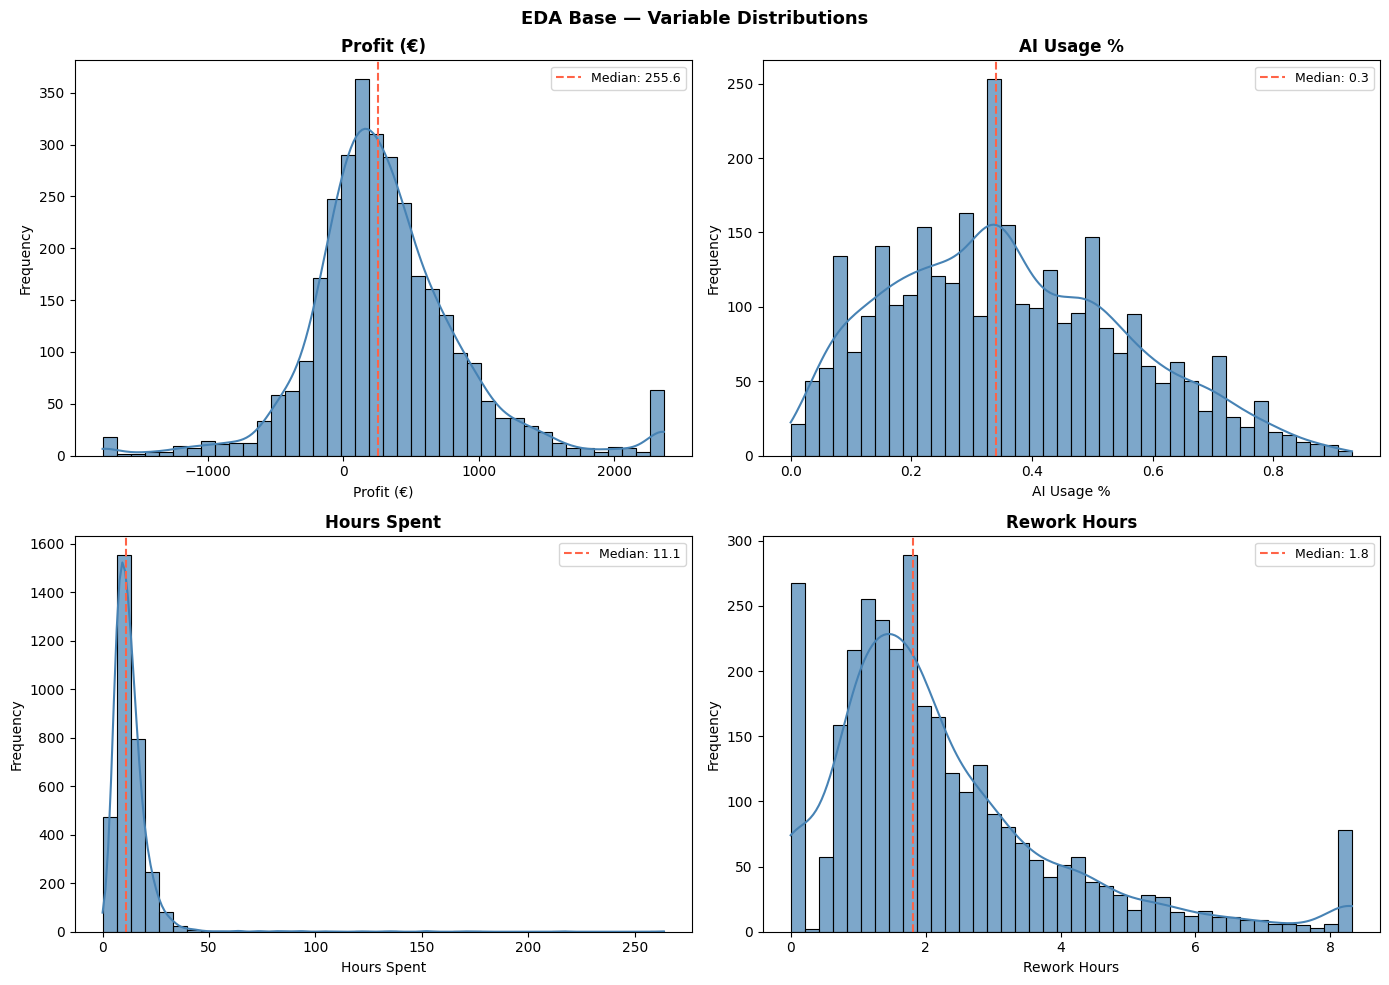

In [619]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA Base — Variable Distributions', fontsize=13, fontweight='bold')

vars_plot = [
    ('profit',       'Profit (€)'),
    ('ai_usage_pct', 'AI Usage %'),
    ('hours_spent',  'Hours Spent'),
    ('rework_hours', 'Rework Hours'),
]

for ax, (col, label) in zip(axes.flatten(), vars_plot):
    sns.histplot(df_productivity[col].dropna(), bins=40, kde=True,
                 color='steelblue', alpha=0.7, ax=ax)
    
    med = df_productivity[col].median()
    ax.axvline(med, color='tomato', linestyle='--', linewidth=1.5,
               label=f'Median: {med:.1f}')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()


In [620]:
key_vars = [
    'profit', 'ai_usage_pct', 'hours_spent',
    'rework_hours', 'outcome_score', 'revenue'
]

stats_df = pd.DataFrame({
    'mean':     df_productivity[key_vars].mean().round(2),
    'median':   df_productivity[key_vars].median().round(2),
    'std':      df_productivity[key_vars].std().round(2),
    'skewness': df_productivity[key_vars].skew().round(3),
})

print("\n=== Descriptive statistics ===\n")
print(stats_df.to_string())

print("\nVariables with |skewness| > 1:")
print(stats_df[stats_df['skewness'].abs() > 1].index.tolist())


=== Descriptive statistics ===

                  mean  median     std  skewness
profit          321.39  255.60  591.02     0.648
ai_usage_pct      0.36    0.34    0.19     0.396
hours_spent      13.02   11.10   11.42     9.954
rework_hours      2.26    1.81    1.78     1.475
outcome_score    68.90   69.40   12.35    -0.338
revenue        1083.79  966.04  628.68     1.493

Variables with |skewness| > 1:
['hours_spent', 'rework_hours', 'revenue']


oppure:

In [621]:
print("\nSkewness:")
skew_cols = ['profit', 'ai_usage_pct', 'hours_spent', 'rework_hours']
print(df_productivity[skew_cols].skew())


Skewness:
profit          0.647854
ai_usage_pct    0.395837
hours_spent     9.953660
rework_hours    1.474618
dtype: float64


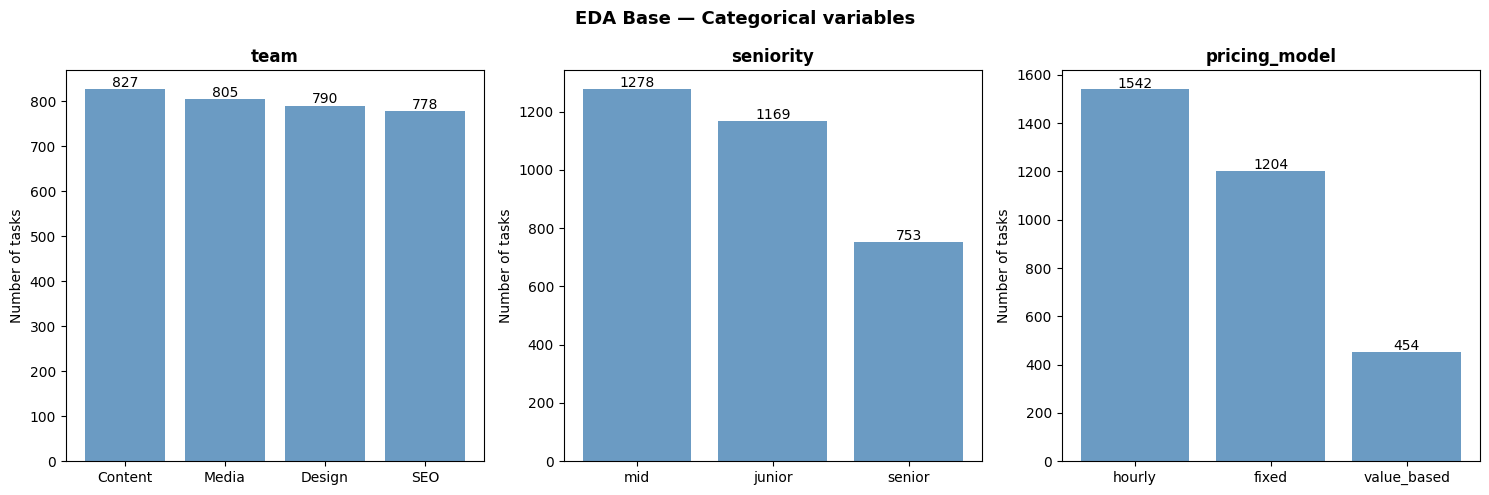

In [622]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA Base — Categorical variables', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['team', 'seniority', 'pricing_model']):
    counts = df_productivity[col].value_counts()
    
    ax.bar(counts.index, counts.values, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Number of tasks')
    
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()


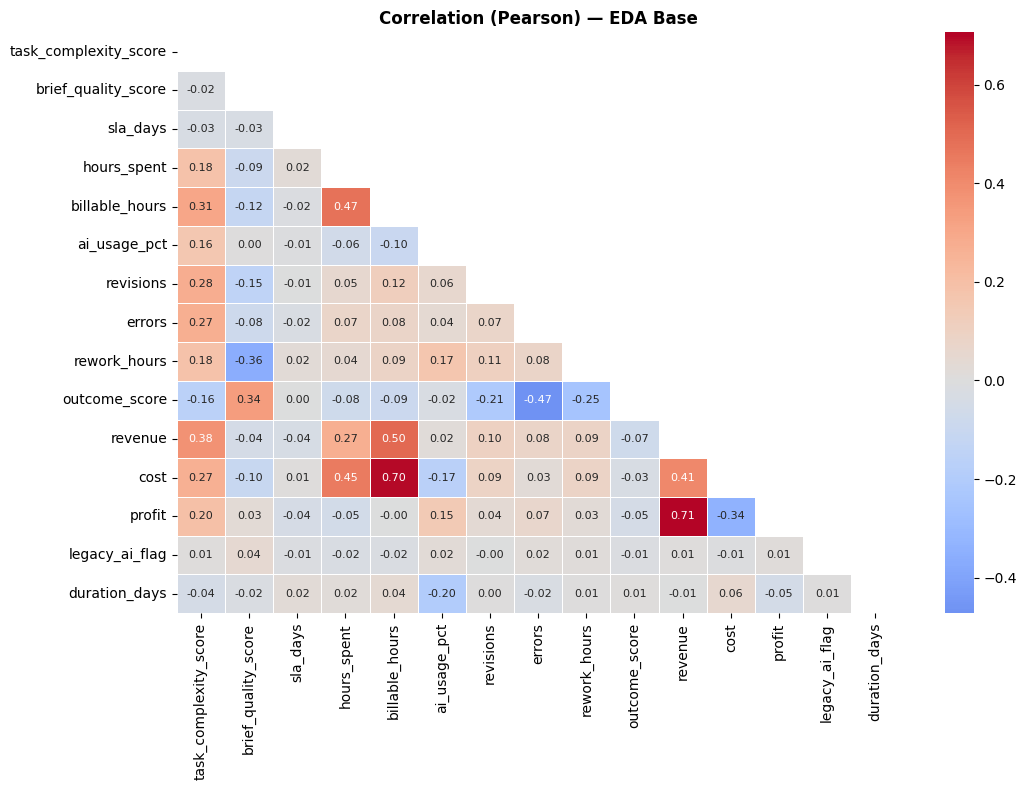

In [623]:

numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Pearson) — EDA Base', fontweight='bold')
plt.tight_layout()
plt.show()

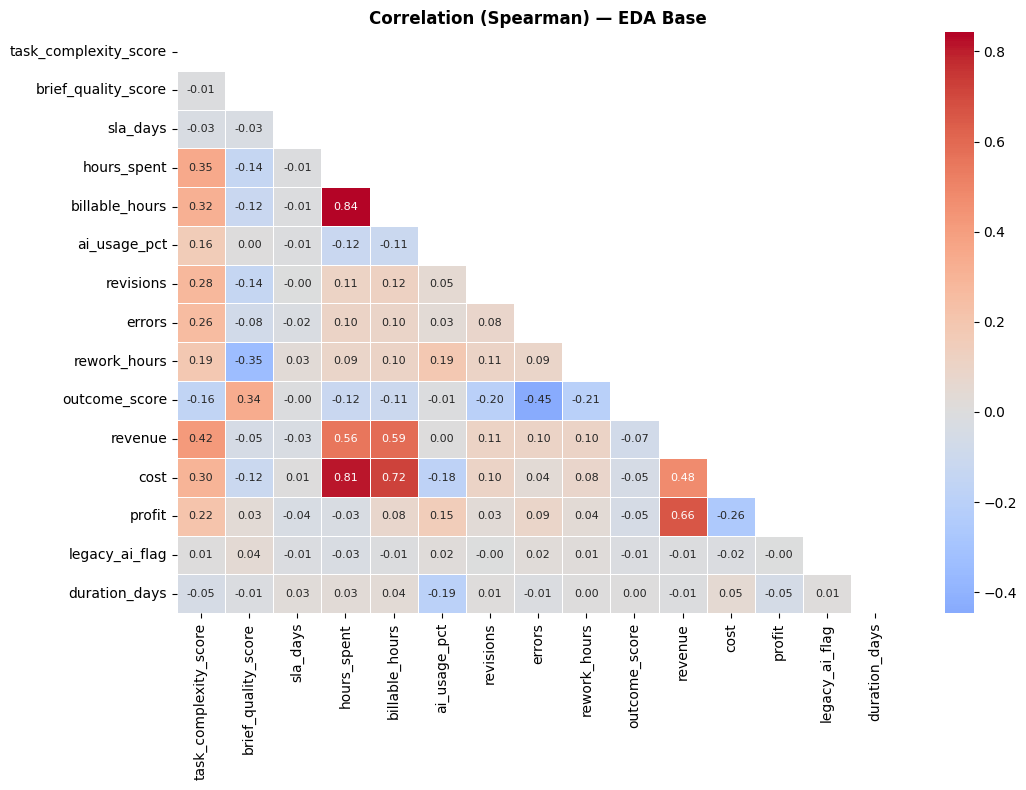

In [624]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Spearman) — EDA Base', fontweight='bold')
plt.tight_layout()
plt.show()

In [625]:
print("\nKey Statistics:")
print(df_productivity[[
    'profit',
    'ai_usage_pct',
    'hours_spent',
    'rework_hours'
]].describe())


Key Statistics:
            profit  ai_usage_pct  hours_spent  rework_hours
count  3200.000000   3200.000000  3200.000000   3200.000000
mean    321.389776      0.360997    13.021995      2.260933
std     591.017943      0.194997    11.423119      1.775209
min   -1777.785000      0.000000     0.020000      0.000000
25%      -2.040000      0.210000     7.900000      1.120000
50%     255.600000      0.340000    11.100000      1.810000
75%     589.875000      0.500000    15.322500      2.920000
max    2365.620000      0.930000   263.600180      8.320000


In [626]:
df_productivity['ai_usage_pct'].describe()

count    3200.000000
mean        0.360997
std         0.194997
min         0.000000
25%         0.210000
50%         0.340000
75%         0.500000
max         0.930000
Name: ai_usage_pct, dtype: float64

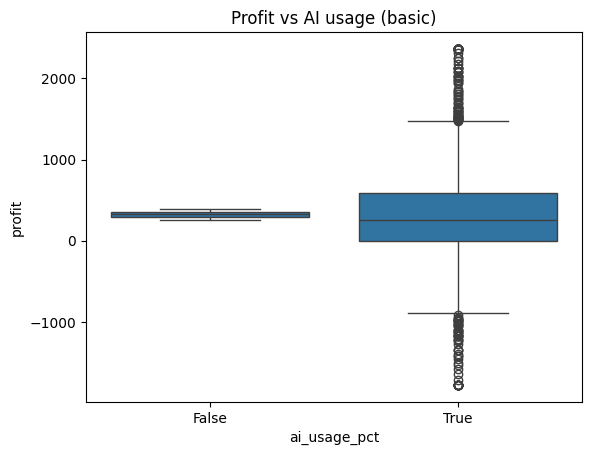

In [627]:
sns.boxplot(x=df_productivity['ai_usage_pct'] > 0,
            y=df_productivity['profit'])
plt.title("Profit vs AI usage (basic)")
plt.show()

In [628]:
print("\nBasic correlations with profit:")
print(df_productivity[['profit','revenue','cost','hours_spent']].corr()['profit'])


Basic correlations with profit:
profit         1.000000
revenue        0.706309
cost          -0.336052
hours_spent   -0.053798
Name: profit, dtype: float64


In [629]:
print("\nAI vs key variables (mean):")
print(df_productivity.groupby(df_productivity['ai_usage_pct'] > 0)[
    ['profit','hours_spent','rework_hours']
].mean())


AI vs key variables (mean):
                  profit  hours_spent  rework_hours
ai_usage_pct                                       
False         322.515000     8.210000       1.53000
True          321.389072    13.025005       2.26139


# Feature Engineering (EDA-driven)

In [630]:
df_productivity.loc[
    df_productivity['billable_hours'] < 0,
    'billable_hours'
] = np.nan


In [631]:
# 1

df_productivity['profit_margin'] = (
    df_productivity['profit'] / df_productivity['revenue'].replace(0, np.nan)
) * 100

df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# 2
min_hours = 0.1
hours_safe = df_productivity['hours_spent'].clip(lower=min_hours)

df_productivity['rework_rate'] = df_productivity['rework_hours'] / hours_safe
df_productivity['error_rate']  = df_productivity['errors']       / hours_safe


# 3 

df_productivity['billable_ratio']   = df_productivity['billable_hours'] / hours_safe
df_productivity['revenue_per_hour'] = df_productivity['revenue']        / hours_safe
df_productivity['cost_per_hour']    = df_productivity['cost']           / hours_safe

# 4
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# 5

median_cph = df_productivity['cost_per_hour'].median()
df_productivity['rework_cost_est']  = df_productivity['rework_hours'] * median_cph
df_productivity['hidden_cost_ratio'] = (
    df_productivity['rework_cost_est'] / df_productivity['cost'].replace(0, np.nan)
)
print(f"Median cost/hour used: €{median_cph:.2f}")

# 6

bins = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
df_productivity['ai_bucket'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=bins,
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'],
    include_lowest=True
)

# 7

df_productivity['is_high_ai'] = (df_productivity['ai_usage_pct'] >= 0.6).astype(int)

# 8

df_productivity['budget_bucket'] = pd.qcut(
    df_productivity['revenue'], q=2,
    labels=['low_budget', 'high_budget']
)
df_productivity['profit_bucket'] = pd.qcut(
    df_productivity['profit'], q=2,
    labels=['low_profit', 'high_profit']
)
df_productivity['complexity_bucket'] = pd.qcut(
    df_productivity['task_complexity_score'], q=3,
    labels=['low', 'medium', 'high']
)

# 9

df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

neg = (df_productivity['duration_days'] < 0).sum()
if neg > 0:
    df_productivity.loc[df_productivity['duration_days'] < 0, 'duration_days'] = np.nan
print(f"Negative durations fixed: {neg}")

# 10 

def cap_iqr(series, k=3):
    q1    = series.quantile(0.25)
    q3    = series.quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n     = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), n

cap_cols = ['rework_rate', 'error_rate', 'billable_ratio',
            'revenue_per_hour', 'cost_per_hour', 'hidden_cost_ratio', 'profit_margin' ]

print("\nCapping (IQR x 3):\n")
for col in cap_cols:
    df_productivity[col], n = cap_iqr(df_productivity[col])
    print(f"  {col:<25} {n} valori cappati")



Median cost/hour used: €58.06
Negative durations fixed: 14

Capping (IQR x 3):

  rework_rate               70 valori cappati
  error_rate                27 valori cappati
  billable_ratio            18 valori cappati
  revenue_per_hour          89 valori cappati
  cost_per_hour             39 valori cappati
  hidden_cost_ratio         56 valori cappati
  profit_margin             62 valori cappati


In [632]:
df_productivity.replace([np.inf, -np.inf], np.nan, inplace=True)

critical_cols = ['profit_margin', 'rework_rate', 'error_rate', 'billable_ratio']
before = len(df_productivity)
df_productivity.dropna(subset=critical_cols, inplace=True)
after  = len(df_productivity)
print(f"\nRows dropped: {before - after}")
print(f"Remaining rows: {after}")


Rows dropped: 17
Remaining rows: 3183


In [633]:
check_cols = ['profit_margin', 'rework_rate', 'error_rate', 'billable_ratio',
              'revenue_per_hour', 'cost_per_hour', 'hidden_cost_ratio']

print("\n=== Feature summary ===\n")
print(df_productivity[check_cols].describe().round(2))

print("\nEdge cases:")
print(f"rework_rate > 1:    {(df_productivity['rework_rate'] > 1).sum()}")
print(f"billable_ratio > 1: {(df_productivity['billable_ratio'] > 1).sum()}")





=== Feature summary ===

       profit_margin  rework_rate  error_rate  billable_ratio  \
count        3183.00      3183.00     3183.00         3183.00   
mean           18.60         0.22        0.10            0.69   
std            47.55         0.19        0.12            0.18   
min          -154.41         0.00        0.00            0.03   
25%            -0.19         0.09        0.00            0.57   
50%            29.07         0.17        0.07            0.70   
75%            51.18         0.29        0.15            0.81   
max            94.88         0.88        0.59            1.54   

       revenue_per_hour  cost_per_hour  hidden_cost_ratio  
count           3183.00        3183.00            3183.00  
mean              93.37          60.68               0.22  
std               49.39          19.94               0.20  
min                3.74           2.86               0.00  
25%               61.51          47.01               0.09  
50%               81.48     

In [634]:
print("\nAI bucket distribution:")
print(df_productivity['ai_bucket'].value_counts().sort_index())
print("\nHigh AI flag distribution:")
print(df_productivity['is_high_ai'].value_counts())


AI bucket distribution:
ai_bucket
0-20%       772
20-40%     1206
40-60%      811
60-80%      346
80-100%      48
Name: count, dtype: int64

High AI flag distribution:
is_high_ai
0    2764
1     419
Name: count, dtype: int64


## EDA ADVANCED 

([0, 1, 2, 3, 4],
 [Text(0, 0, '0-20%'),
  Text(1, 0, '20-40%'),
  Text(2, 0, '40-60%'),
  Text(3, 0, '60-80%'),
  Text(4, 0, '80-100%')])

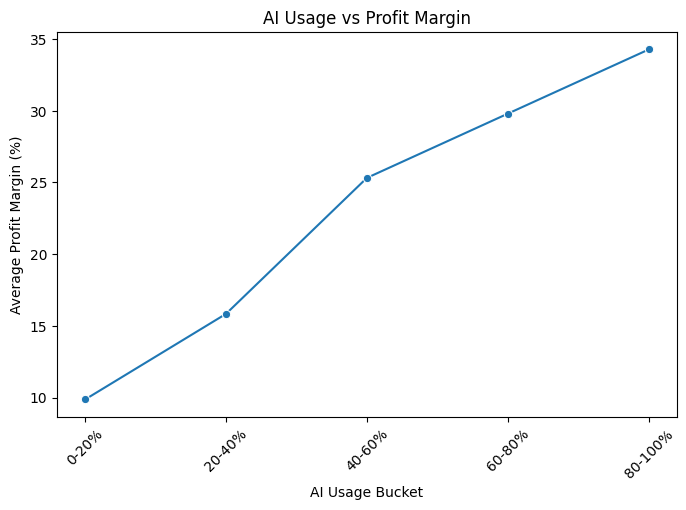

In [642]:
# ============================================================
# AI vs PROFIT (BIVARIATE CORE)
# ============================================================


plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit_margin',
    estimator='mean',
    errorbar=None,
    marker='o'
)

plt.title("AI Usage vs Profit Margin")
plt.xlabel("AI Usage Bucket")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=45)


Text(0, 0.5, 'Profit Margin (%)')

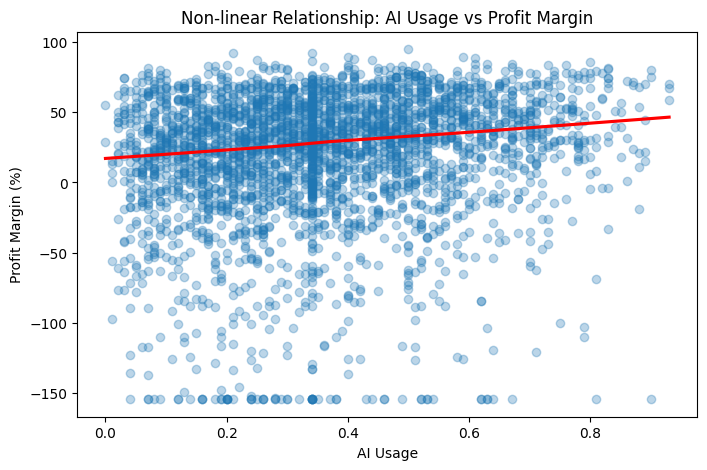

In [643]:
# ============================================================
# NON-LINEAR EFFECT (LOWESS)
# ============================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=df_productivity,
    x='ai_usage_pct',
    y='profit_margin',
    lowess=True,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Non-linear Relationship: AI Usage vs Profit Margin")
plt.xlabel("AI Usage")
plt.ylabel("Profit Margin (%)")


([0, 1, 2, 3, 4],
 [Text(0, 0, '0-20%'),
  Text(1, 0, '20-40%'),
  Text(2, 0, '40-60%'),
  Text(3, 0, '60-80%'),
  Text(4, 0, '80-100%')])

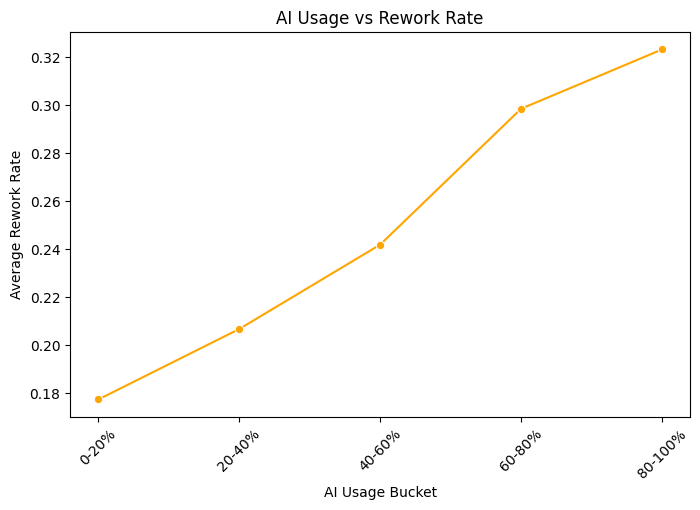

In [644]:
# ============================================================
# AI → REWORK
# ============================================================

plt.figure(figsize=(8,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_rate',
    estimator='mean',
    errorbar=None,
    marker='o',
    color='orange'
)

plt.title("AI Usage vs Rework Rate")
plt.xlabel("AI Usage Bucket")
plt.ylabel("Average Rework Rate")
plt.xticks(rotation=45)


Text(0, 0.5, 'Profit Margin (%)')

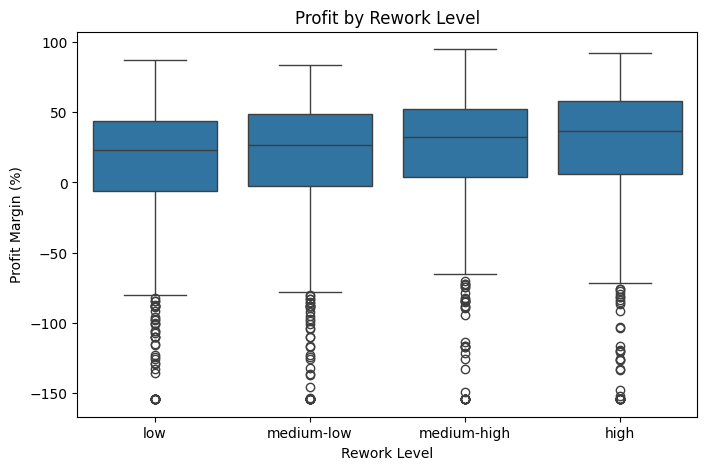

In [645]:
# ============================================================
# REWORK → PROFIT
# ============================================================

# crea bin di rework
df_productivity['rework_bin'] = pd.qcut(
    df_productivity['rework_rate'],
    q=4,
    labels=['low', 'medium-low', 'medium-high', 'high']
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_productivity,
    x='rework_bin',
    y='profit_margin'
)

plt.title("Profit by Rework Level")
plt.xlabel("Rework Level")
plt.ylabel("Profit Margin (%)")


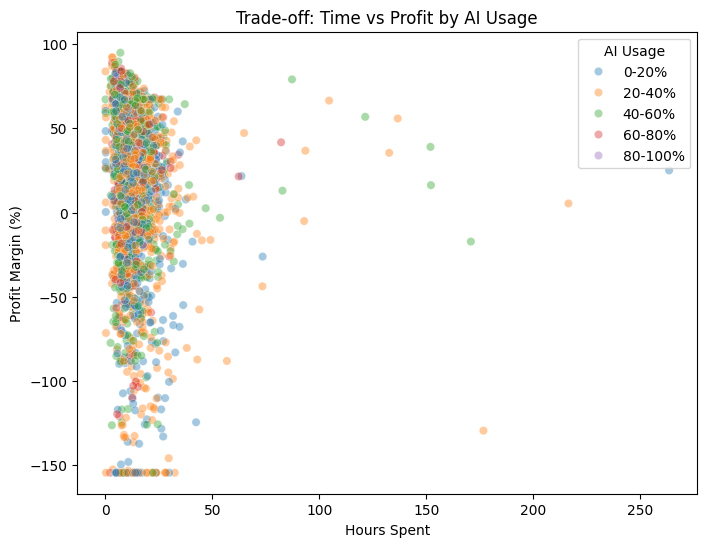

In [646]:
# ============================================================
# TRADE-OFF: TIME vs PROFIT (color = AI)
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_productivity,
    x='hours_spent',
    y='profit_margin',
    hue='ai_bucket',
    alpha=0.4
)

plt.title("Trade-off: Time vs Profit by AI Usage")
plt.xlabel("Hours Spent")
plt.ylabel("Profit Margin (%)")
plt.legend(title="AI Usage")


Text(0, 0.5, 'Profit Margin (%)')

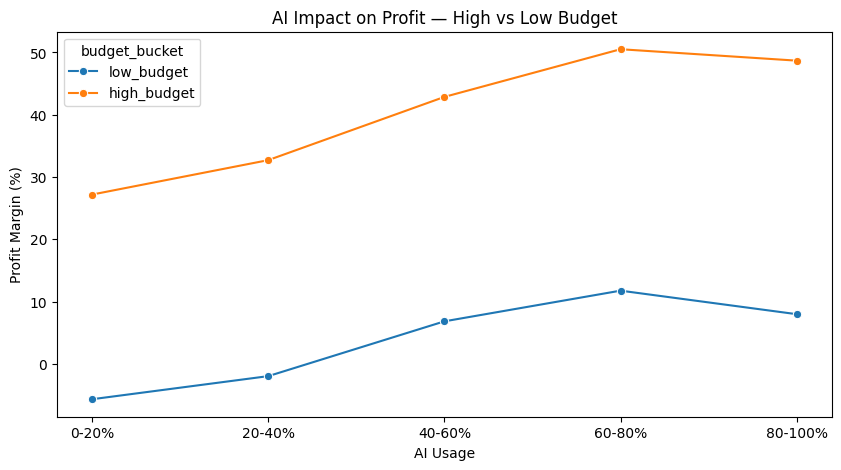

In [647]:
# ============================================================
# SEGMENTATION — BUDGET
# ============================================================

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit_margin',
    hue='budget_bucket',
    estimator='mean',
    errorbar=None,
    marker='o'
)

plt.title("AI Impact on Profit — High vs Low Budget")
plt.xlabel("AI Usage")
plt.ylabel("Profit Margin (%)")


Text(0, 0.5, 'Profit Margin (%)')

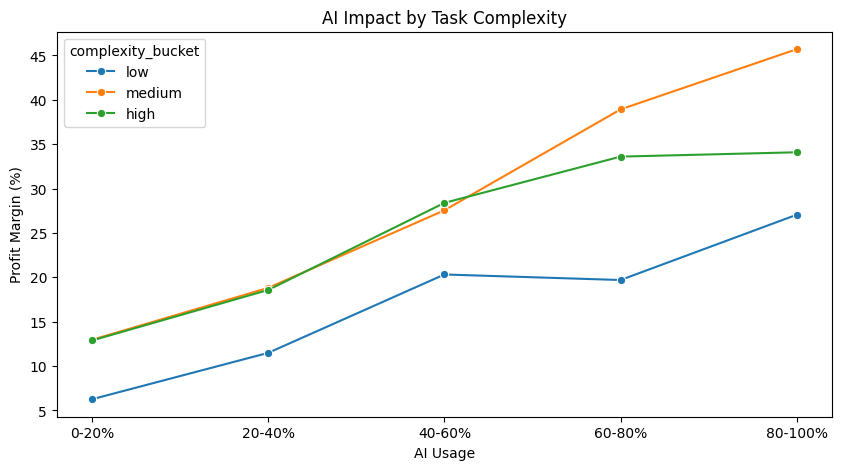

In [648]:
# ============================================================
# SEGMENTATION — COMPLEXITY
# ============================================================

plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit_margin',
    hue='complexity_bucket',
    estimator='mean',
    errorbar=None,
    marker='o'
)

plt.title("AI Impact by Task Complexity")
plt.xlabel("AI Usage")
plt.ylabel("Profit Margin (%)")


In [649]:
# ============================================================
# AI vs NO AI (clean version)
# ============================================================

comparison = df_productivity.groupby('ai_flag')[[
    'profit_margin',
    'rework_rate',
    'hours_spent',
    'hidden_cost_ratio'
]].mean()

print(comparison.round(2))

         profit_margin  rework_rate  hours_spent  hidden_cost_ratio
ai_flag                                                            
0                42.12         0.23         8.21               0.26
1                18.59         0.22        13.03               0.22



# Trade-off Analysis


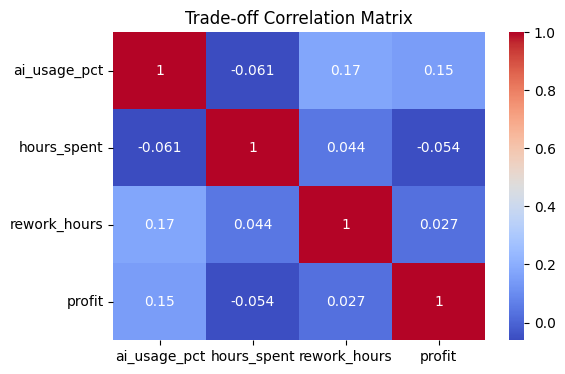

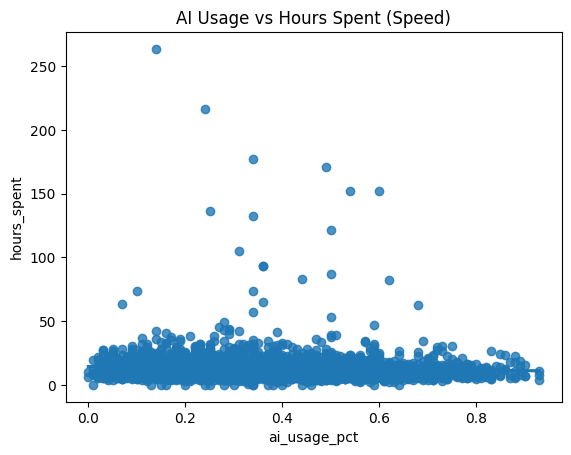

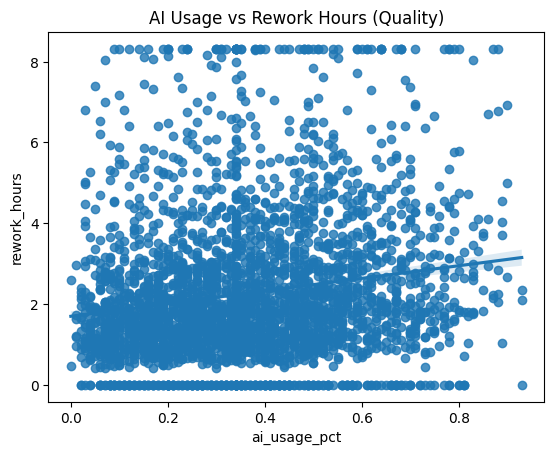

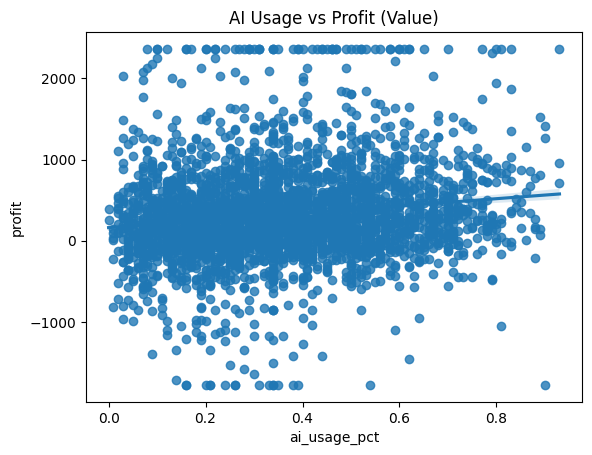

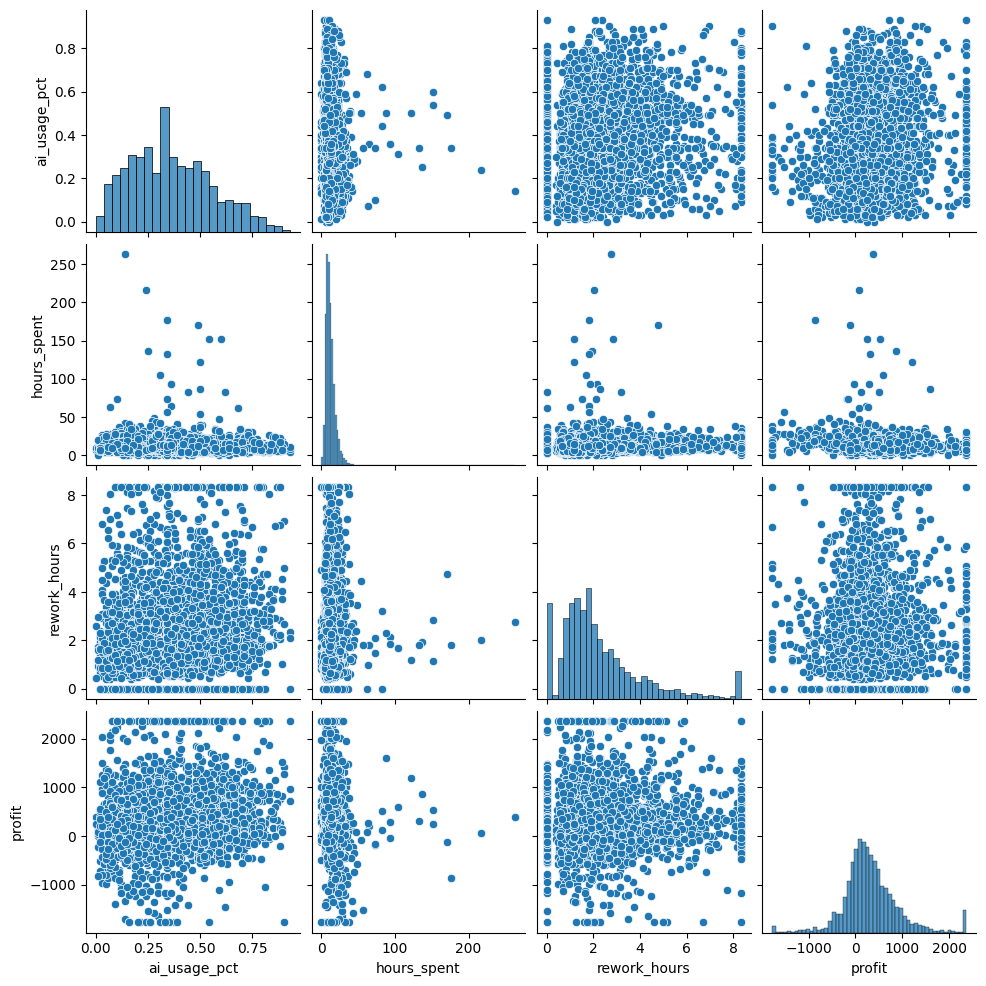

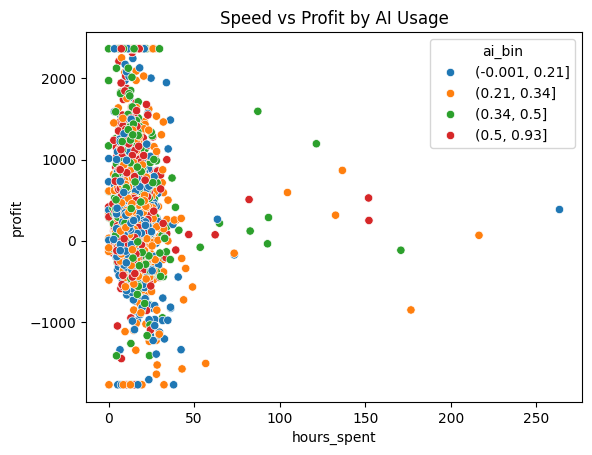

In [299]:

# 1. Correlation tra variabili chiave
tradeoff_corr = df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(tradeoff_corr, annot=True, cmap='coolwarm')
plt.title("Trade-off Correlation Matrix")
plt.show()


# 2. AI vs Speed (tempo)
sns.regplot(x='ai_usage_pct', y='hours_spent', data=df_productivity)
plt.title("AI Usage vs Hours Spent (Speed)")
plt.show()


# 3. AI vs Quality (rework)
sns.regplot(x='ai_usage_pct', y='rework_hours', data=df_productivity)
plt.title("AI Usage vs Rework Hours (Quality)")
plt.show()


# 4. AI vs Profit (valore)
sns.regplot(x='ai_usage_pct', y='profit', data=df_productivity)
plt.title("AI Usage vs Profit (Value)")
plt.show()


# 5. Visione globale (tutte le relazioni insieme)
sns.pairplot(df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']])
plt.show()


# 6. Trade-off avanzato: Speed vs Profit colorato per AI
df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=4)

sns.scatterplot(
    x='hours_spent',
    y='profit',
    hue='ai_bin',
    data=df_productivity
)
plt.title("Speed vs Profit by AI Usage")
plt.show()

# Non linear effect of AI
AI aumenta il profit sempre allo stesso modo?
👉 oppure cambia comportamento (non lineare)

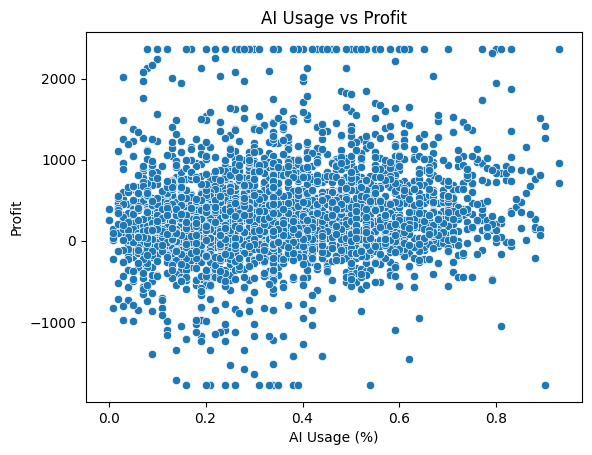

In [300]:
# =========================
# AI vs Profit (base)
# =========================

sns.scatterplot(x='ai_usage_pct', y='profit', data=df_productivity)
plt.title("AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

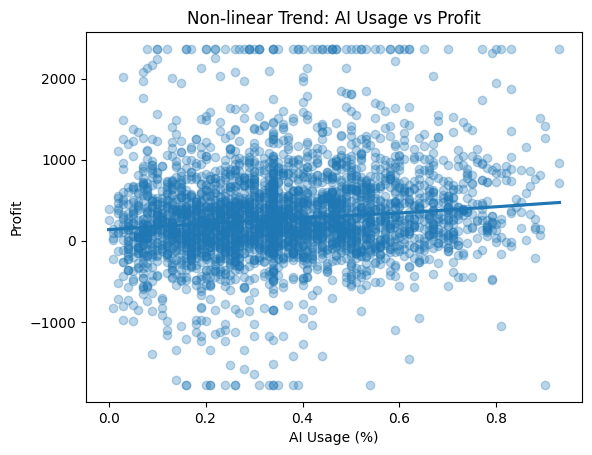

In [301]:
# =========================
# Non-linear trend (LOWESS)
# =========================

sns.regplot(
    x='ai_usage_pct',
    y='profit',
    data=df_productivity,
    lowess=True,
    scatter_kws={'alpha':0.3}
)

plt.title("Non-linear Trend: AI Usage vs Profit")
plt.xlabel("AI Usage (%)")
plt.ylabel("Profit")
plt.show()

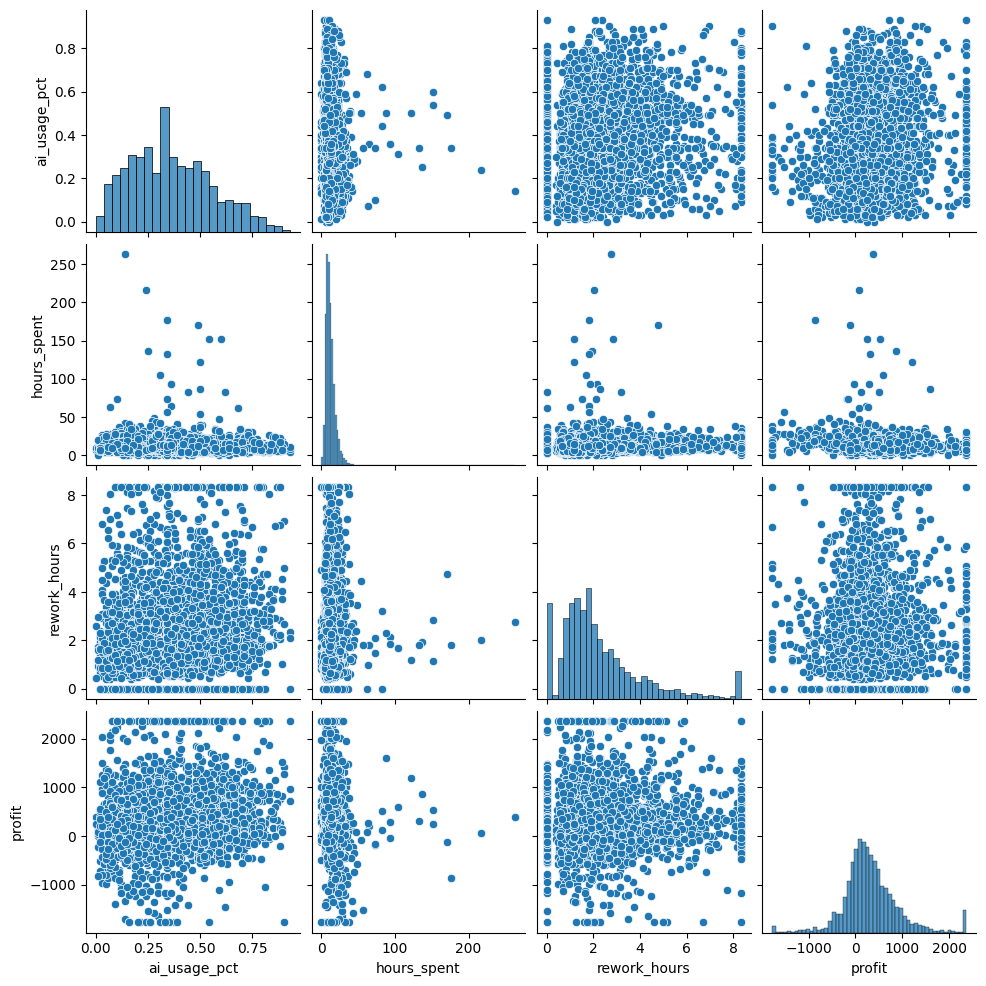

In [302]:
sns.pairplot(df_productivity[['ai_usage_pct', 'hours_spent', 'rework_hours', 'profit']])
plt.show()

In [303]:
# =========================
# Binning AI usage
# =========================

df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=5)

ai_bin_analysis = df_productivity.groupby('ai_bin')['profit'].mean()

print(ai_bin_analysis)

ai_bin
(-0.001, 0.18]    224.322409
(0.18, 0.3]       252.124982
(0.3, 0.39]       302.742217
(0.39, 0.53]      392.941462
(0.53, 0.93]      443.922529
Name: profit, dtype: float64


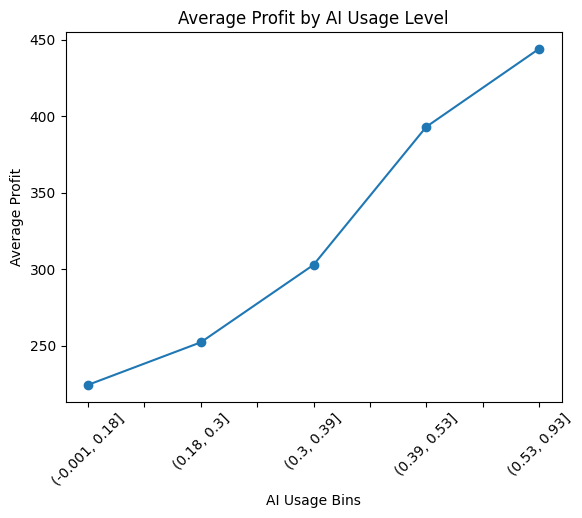

In [304]:
ai_bin_analysis.plot(kind='line', marker='o')

plt.title("Average Profit by AI Usage Level")
plt.xlabel("AI Usage Bins")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.show()

# Threshold detection
“fino a che livello AI aiuta… e da quando smette (o peggiora)?”

In [305]:
df_productivity['ai_bin'] = pd.qcut(df_productivity['ai_usage_pct'], q=5)

In [306]:
# =========================
# Average profit per bin
# =========================

ai_threshold = df_productivity.groupby('ai_bin')['profit'].mean()

print(ai_threshold)

ai_bin
(-0.001, 0.18]    224.322409
(0.18, 0.3]       252.124982
(0.3, 0.39]       302.742217
(0.39, 0.53]      392.941462
(0.53, 0.93]      443.922529
Name: profit, dtype: float64


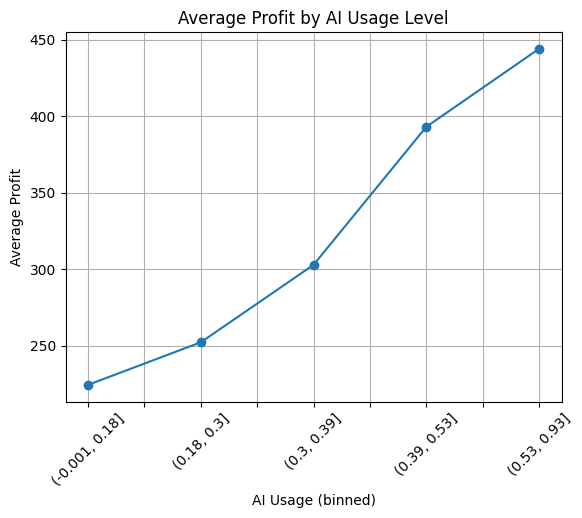

In [307]:
# =========================
# Plot threshold
# =========================

ai_threshold.plot(kind='line', marker='o')

plt.title("Average Profit by AI Usage Level")
plt.xlabel("AI Usage (binned)")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# Loss Analysis 

1.	AI → cambia tempo
2.	AI → cambia rework
3.	rework → ha un costo
4.	costo → impatta profit

⸻

quindi:

AI non impatta direttamente il profit
lo fa tramite costi operativi

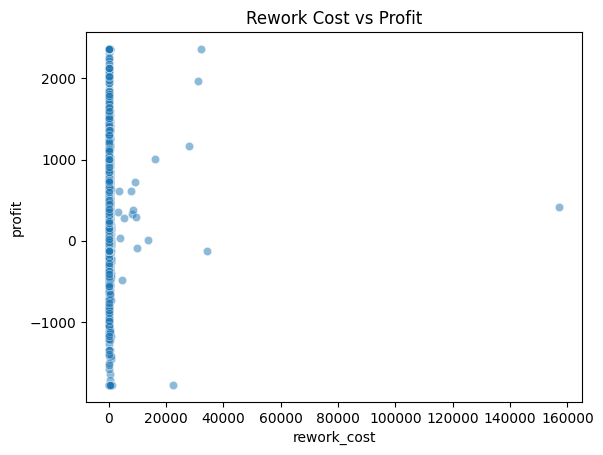

rework_bin
(-0.001, 60.177]         395.770222
(60.177, 104.253]        334.010542
(104.253, 177.251]       322.370692
(177.251, 157249.387]    233.407648
Name: profit, dtype: float64


In [308]:
df_productivity['rework_cost'] = (
    df_productivity['rework_hours'] * df_productivity['cost_per_hour']
)

# relazione
sns.scatterplot(x='rework_cost', y='profit', data=df_productivity, alpha=0.5)
plt.title("Rework Cost vs Profit")
plt.show()

# binning
df_productivity['rework_bin'] = pd.qcut(df_productivity['rework_cost'], q=4)

loss_analysis = df_productivity.groupby('rework_bin')['profit'].mean()

print(loss_analysis)

In [309]:
df_productivity[['rework_cost', 'profit']].corr()

,rework_cost,profit
rework_cost,1.000000,0.010984
profit,0.010984,1.000000


In [310]:
df_productivity['rework_bin'] = pd.qcut(df_productivity['rework_cost'], q=4)

df_productivity.groupby('rework_bin')['profit'].mean()

rework_bin
(-0.001, 60.177]         395.770222
(60.177, 104.253]        334.010542
(104.253, 177.251]       322.370692
(177.251, 157249.387]    233.407648
Name: profit, dtype: float64

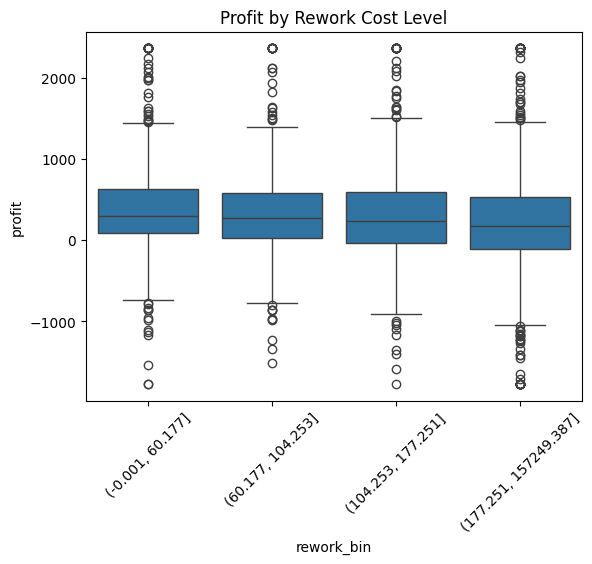

In [311]:
sns.boxplot(x='rework_bin', y='profit', data=df_productivity)
plt.title("Profit by Rework Cost Level")
plt.xticks(rotation=45)
plt.show()